# Linear Regression

In [1038]:
!python --version

Python 3.11.5


## Importing

In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

## Reading

In [1025]:
data = pd.read_csv('tourist_data.csv')
data['date'] = pd.to_datetime(data['date'])

data['tourist_arrivals'] = data['tourist_arrivals'].replace(',', '', regex=True)

# Convert the column to floats
data['tourist_arrivals'] = data['tourist_arrivals'].astype(float)

data.tail()
data = data[(data['date']> '2023-10-01')]

In [1026]:
data = data.sort_values(by=['date'],ascending=True)
data = data[['exchange_rate', 'tourist_arrivals']]


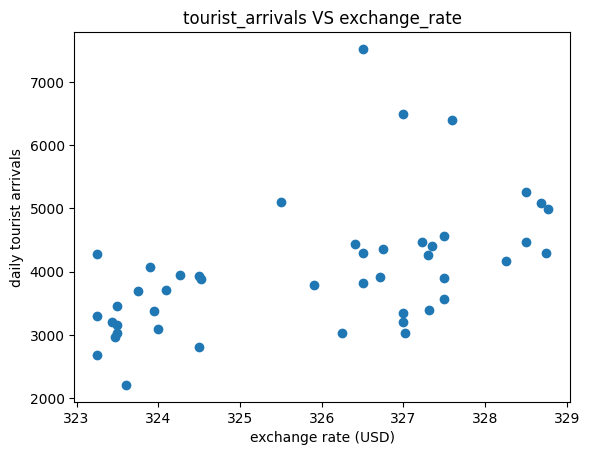

In [1027]:
plt.scatter(data['exchange_rate'], data['tourist_arrivals'])
plt.title('tourist_arrivals VS exchange_rate')
plt.ylabel('daily tourist arrivals')
plt.xlabel('exchange rate (USD)')
plt.show()

In [1028]:
data.var()

exchange_rate       3.472999e+00
tourist_arrivals    1.055017e+06
dtype: float64

In [1029]:
# data['tourist_arrivals'] = (data['tourist_arrivals']/1000)
# data['exchange_rate_scaled'] = (data['exchange_rate'])

In [1030]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data[['exchange_rate', 'tourist_arrivals']])

In [1031]:
print(f'exchange_rate_scaled: {data_scaled[:,0].var()} \ntourist_arrivals_scaled: {data_scaled[:,1].var()}')

exchange_rate_scaled: 1.0000000000000002 
tourist_arrivals_scaled: 1.0000000000000002


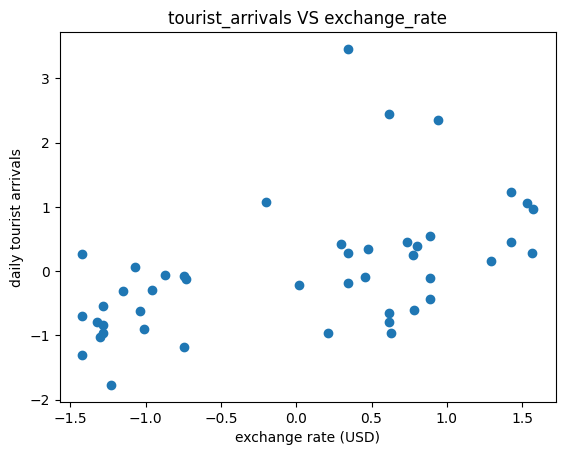

In [1036]:
plt.scatter(data_scaled[:,0], data_scaled[:,1])
plt.title('tourist_arrivals VS exchange_rate')
plt.ylabel('daily tourist arrivals')
plt.xlabel('exchange rate (USD)')
plt.show()

## Algorithm

### Cost function

In [ ]:

#Cost Function
def loss_func(m, b, data):
    total_error = 0
    for i in range(len(data)):
        x = data.iloc[i].exchange_rate
        y = data.iloc[i].tourist_arrivals
        total_error += (y - (m*x + b))**2
    return total_error/float(len(data))
        

In [ ]:
data_scaled[2][0]

### Gradient Descent

In [1015]:
def initialization(data):
    x_mean = data.exchange_rate_scaled.mean()
    y_mean = data.tourist_arrivals_scaled.mean()
    cov_x_y = 0
    var_x = 0
    
    for i in range(len(data)):
        # x = data.iloc[i].exchange_rate_scaled
        # y = data.iloc[i].tourist_arrivals_scaled
        x = data_scaled[i][0]
        y = data_scaled[i][1]
        cov_x_y += ((x - x_mean)*(y - y_mean))
        var_x += (x - x_mean)**2 
        
    m = cov_x_y/var_x 
    b = y_mean - (beta * x_mean) 

    return m, b

def gradient_descent(m_curr, b_curr, data, learning_rate):
    
    m_grad = 0
    b_grad = 0
    
    n = len(data)
    
    abs_error = 0
    
    for i in range(n):
        x = data_scaled[i][0]
        y = data_scaled[i][1]
        
        pred = (m_curr * x) + b_curr
        error = (y - pred)
        m_grad += -(2/n) * x * error
        b_grad += -(2/n) * error
        
        abs_error += abs(error)
        
    abs_mean_error = abs_error/n
    m =  m_curr - (m_grad * learning_rate)
    b =  b_curr - (b_grad * learning_rate)
    
    # print(f'error: {error}')
    return abs_mean_error, m, b


Epoch: 0, MAE: 2.814816215777652
Epoch: 20, MAE: 1.9526490921055875
Epoch: 40, MAE: 1.404666412804929
Epoch: 60, MAE: 1.055908853602648
Epoch: 80, MAE: 0.8310886120911161
Epoch: 100, MAE: 0.7013186126611045
Epoch: 120, MAE: 0.6386633235197684
Epoch: 140, MAE: 0.611729045428989
Epoch: 160, MAE: 0.6009509326150559
Epoch: 180, MAE: 0.5945672157851128
Epoch: 200, MAE: 0.5913881028814958
Epoch: 220, MAE: 0.5898017060996776
Epoch: 240, MAE: 0.5889452943664202
Epoch: 260, MAE: 0.5887791554275859
Epoch: 280, MAE: 0.5888454880150067
Epoch: 300, MAE: 0.5888897721791561
Epoch: 320, MAE: 0.5889193366401646
Epoch: 340, MAE: 0.5889390741100142
Epoch: 360, MAE: 0.5889522510022286
Epoch: 380, MAE: 0.5889610480005137
Epoch: 400, MAE: 0.5889669209466966
Epoch: 420, MAE: 0.5889708417723857
Epoch: 440, MAE: 0.5889734593468716
Epoch: 460, MAE: 0.5889752068604651
Epoch: 480, MAE: 0.588976373514471
Epoch: 500, MAE: 0.5889771523819854
Epoch: 520, MAE: 0.5889776723601471
Epoch: 540, MAE: 0.5889780195017129
Epo

Text(0, 0.5, 'cost')

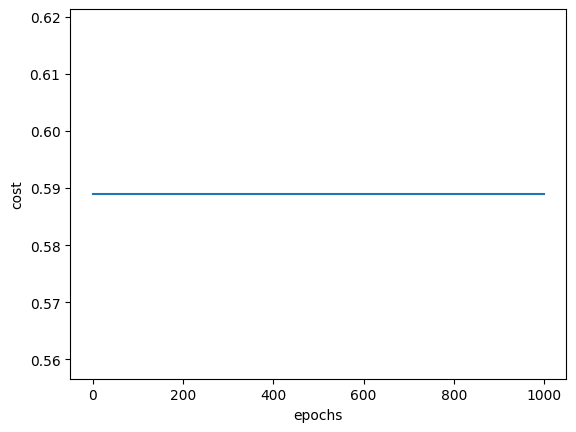

In [1016]:
learning_rate = 0.01
epochs = 1000
errors = []

# m_scaled, b_scaled = initialization(data)
m_scaled = np.random.randn()  
b_scaled = np.random.randn()

for i in range(epochs):
            
    mae, m_scaled, b_scaled = gradient_descent(m_scaled, b_scaled, data, learning_rate)
    
    if i % 20 == 0:
            print(f'Epoch: {i}, MAE: {mae}')
    errors.append(error)

print(f'Final Coefficients: m={m_scaled}, b={b_scaled}')

plt.plot(range(epochs), errors)
plt.xlabel('epochs')
plt.ylabel('cost')

In [ ]:
predictions = [(m_scaled * x + b_scaled) for x in data_scaled[:,0]]
predictions = pd.DataFrame ({'exchange_rate': data_scaled[:,0], 'preds': predictions})

In [ ]:
final_df = scaler.inverse_transform(predictions)

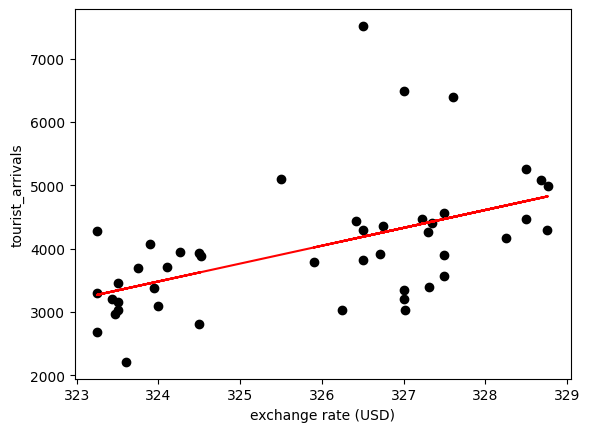

In [1021]:
plt.scatter(data.exchange_rate, data.tourist_arrivals, color="black")
plt.ylabel('tourist_arrivals')
plt.xlabel('exchange rate (USD)')
plt.plot(data.exchange_rate, final_df[:,1], color="red")

In [ ]:
final_df[:,1]

Using linear regression from scikit learn

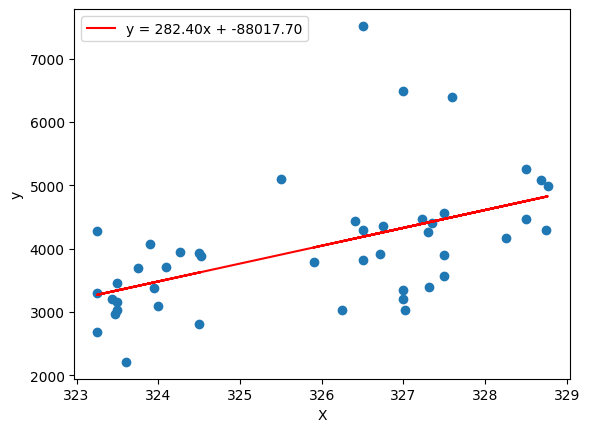

In [1024]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

    
# Assuming you have a dataset X (features) and y (target variable)
# Replace X and y with your actual data

X = data.exchange_rate.values
y = data.tourist_arrivals

# Reshape X if it's a single feature
X = X.reshape(-1, 1)

# Create a Linear Regression model
model = LinearRegression()

# Fit the model to the data
model.fit(X, y)

# Get the coefficients (slope and intercept)
m = model.coef_[0]  # slope
b = model.intercept_  # intercept

# Generate points for the line
# x_line = np.linspace(min(X), max(X), 100).reshape(-1, 1)
y_line = model.predict(X)

# Plot the original data points
plt.scatter(X, y)

# Plot the linear regression line
plt.plot(X, y_line, color='red', label=f'y = {m:.2f}x + {b:.2f}')

# Label the axes
plt.xlabel('X')
plt.ylabel('y')

# Add a legend
plt.legend()

# Show the plot
plt.show()


## FInal comparison

In [1023]:
mae_scratch = sum(abs(data.tourist_arrivals - final_df[:,1]))/len(data)
mae_scikit = sum(abs(data.tourist_arrivals - y_line))/len(data)

print(f'MAE from scratch: {mae_scratch} \nMAE from scikit_learn: {mae_scikit}')

MAE from scratch: 598.2042084847483 
MAE from scikit_learn: 598.2042084753595
